# **Heart Disease Prediction using Machine Learning**

In [43]:
import warnings
warnings.filterwarnings('ignore')

import pickle
import joblib
from datetime import datetime
import os

# Core data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Machine learning pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import RFECV, SelectKBest, f_classif

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Evaluation Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, roc_auc_score, confusion_matrix,
                           classification_report, matthews_corrcoef)
from sklearn.metrics import confusion_matrix, roc_curve, auc

In [44]:
# Define column names based on the UCI documentation
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

# Use na_values='?' because missing data is marked with '?' in these files
cleveland = pd.read_csv('processed.cleveland.data', names=columns, na_values='?')
hungary = pd.read_csv('processed.hungarian.data', names=columns, na_values='?')
switzerland = pd.read_csv('processed.switzerland.data', names=columns, na_values='?')
va = pd.read_csv('processed.va.data', names=columns, na_values='?')

# Merge all data into one DataFrame
df = pd.concat([cleveland, hungary, switzerland, va], ignore_index=True)
print(f"Total records loaded: {len(df)}")

Total records loaded: 920


In [45]:
# Handle missing values by filling them with the median of each column
df = df.fillna(df.median())
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [46]:
# Save the combined and cleaned dataset to a new CSV file
df.to_csv('heart_disease_combined.csv', index=False)
print("File saved successfully as 'heart_disease_combined.csv'")

File saved successfully as 'heart_disease_combined.csv'


## **Data Cleaning**

In [47]:
# Load the already combined dataset
df = pd.read_csv('heart_disease_combined.csv')

**Converting features to categorical features**

In [48]:
# Chest pain type 
df['cp'][df['cp'] == 1] = 'typical angina'
df['cp'][df['cp'] == 2] = 'atypical angina'
df['cp'][df['cp'] == 3] = 'non-anginal pain'
df['cp'][df['cp'] == 4] = 'asymptomatic'
df['cp'].value_counts()


cp
asymptomatic        496
non-anginal pain    204
atypical angina     174
typical angina       46
Name: count, dtype: int64

In [49]:
# Resting Electrocardiographic Results
df['restecg'][df['restecg'] == 0] = 'normal'
df['restecg'][df['restecg'] == 1] = 'ST-T wave abnormality'
df['restecg'][df['restecg'] == 2] = 'left ventricular hypertrophy'
df['restecg'].value_counts()

restecg
normal                          553
left ventricular hypertrophy    188
ST-T wave abnormality           179
Name: count, dtype: int64

In [50]:
# Slope: refers to the orientation of the ST segment on an electrocardiogram (ECG) during peak physical exertion.
df['slope'][df['slope'] == 1] = 'upsloping'
df['slope'][df['slope'] == 2] = 'flat'
df['slope'][df['slope'] == 3] = 'downsloping'
df['slope'].value_counts()

slope
flat           654
upsloping      203
downsloping     63
Name: count, dtype: int64

In [51]:
df["sex"] = df.sex.apply(lambda  x:'male' if x==1 else 'female')

In [52]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,male,typical angina,145.0,233.0,1.0,left ventricular hypertrophy,150.0,0.0,2.3,downsloping,0.0,6.0,0
1,67.0,male,asymptomatic,160.0,286.0,0.0,left ventricular hypertrophy,108.0,1.0,1.5,flat,3.0,3.0,2
2,67.0,male,asymptomatic,120.0,229.0,0.0,left ventricular hypertrophy,129.0,1.0,2.6,flat,2.0,7.0,1
3,37.0,male,non-anginal pain,130.0,250.0,0.0,normal,187.0,0.0,3.5,downsloping,0.0,3.0,0
4,41.0,female,atypical angina,130.0,204.0,0.0,left ventricular hypertrophy,172.0,0.0,1.4,upsloping,0.0,3.0,0


## **Exploratory Data Analysis (EDA)**

### Target Variable Distribution

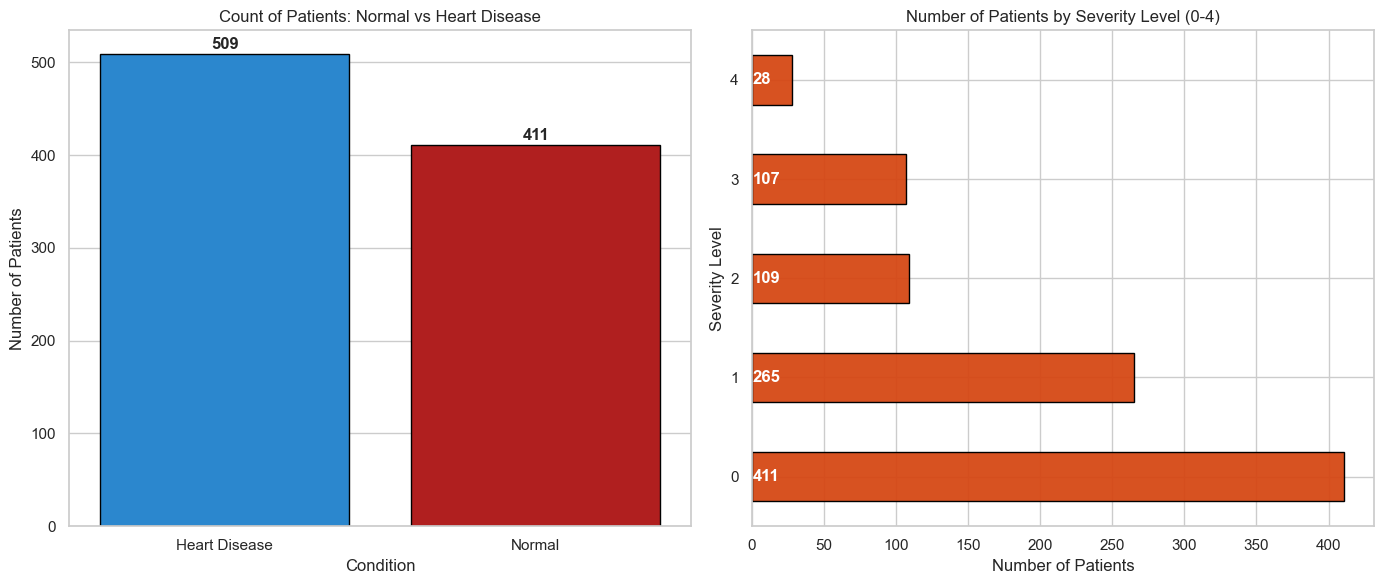

In [53]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, sharey=False, figsize=(14,6))

# Grouping levels 1, 2, 3, and 4 into a single "Heart Disease" group: 0 remains "Normal", everything > 0 is classified as "Heart Disease"
binary_data = df['target'].apply(lambda x: 'Heart Disease' if x > 0 else 'Normal').value_counts()
sns.barplot(x=binary_data.index, y=binary_data.values, ax=ax1, palette=['#108BE9','#C80707'], edgecolor='black')
for i, v in enumerate(binary_data.values):
    ax1.text(i, v + 5, str(v), ha='center', fontsize=12, fontweight='bold')

ax1.set_title('Count of Patients: Normal vs Heart Disease')
ax1.set_xlabel('Condition')
ax1.set_ylabel('Number of Patients')

# Showing the 5 original levels to visualize disease severity
severity_counts = df["target"].value_counts().sort_index()
ax2 = severity_counts.plot(kind="barh", ax=ax2, color="#D54511EE", edgecolor='black')
for i, j in enumerate(severity_counts.values):
    ax2.text(0.5, i, str(j), fontsize=12, color='white', weight='bold', va='center')

ax2.set_title('Number of Patients by Severity Level (0-4)')
ax2.set_xlabel('Number of Patients')
ax2.set_ylabel('Severity Level')

plt.tight_layout()
plt.show()

### Demographic Analysis: Age and Gender Distribution

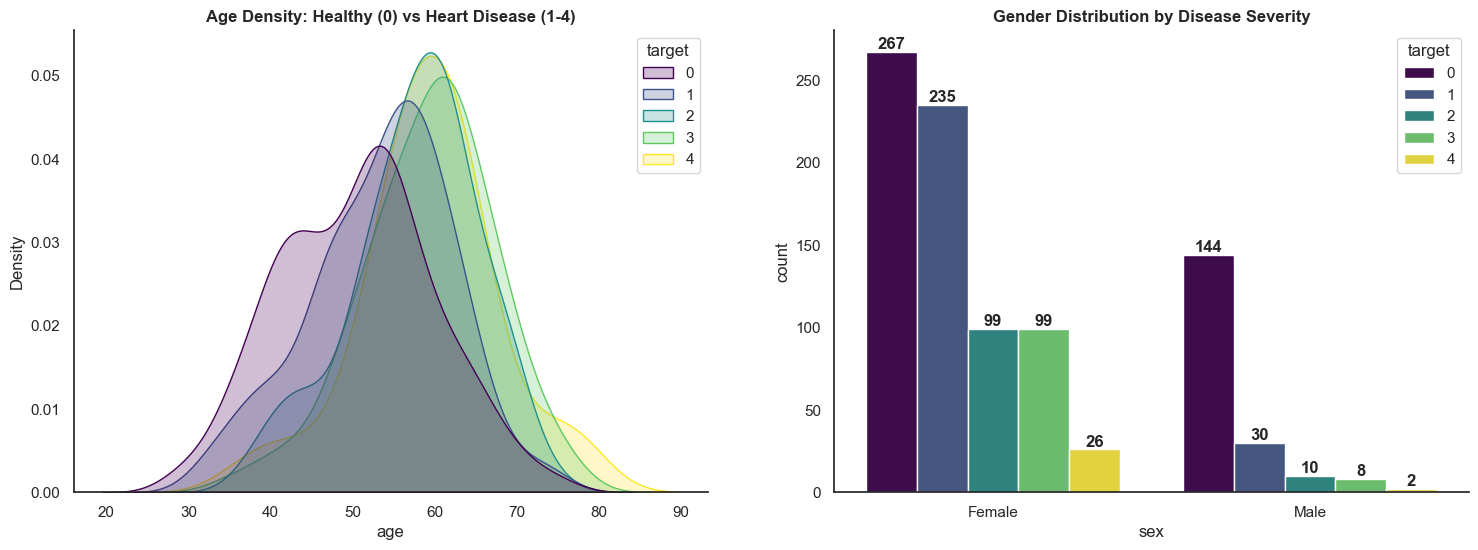

In [54]:
plt.figure(figsize=(18, 6))
sns.set_style("white")

# Age distribution
plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x='age', hue='target', fill=True, palette='viridis', common_norm=False)
plt.title('Age Density: Healthy (0) vs Heart Disease (1-4)', fontweight='bold')

# Gender impact
plt.subplot(1, 2, 2)
ax = sns.countplot(data=df, x='sex', hue='target', palette='viridis')
plt.title('Gender Distribution by Disease Severity', fontweight='bold')
plt.xticks([0, 1], ['Female', 'Male'])
for container in ax.containers:
    ax.bar_label(container, fontweight='bold')

sns.despine()
plt.show()

### Categorical Features Impact on Heart Disease Probability

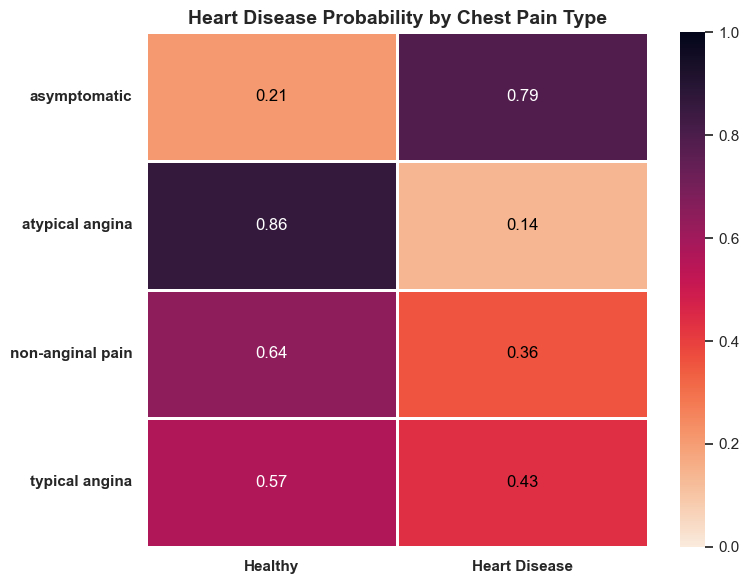

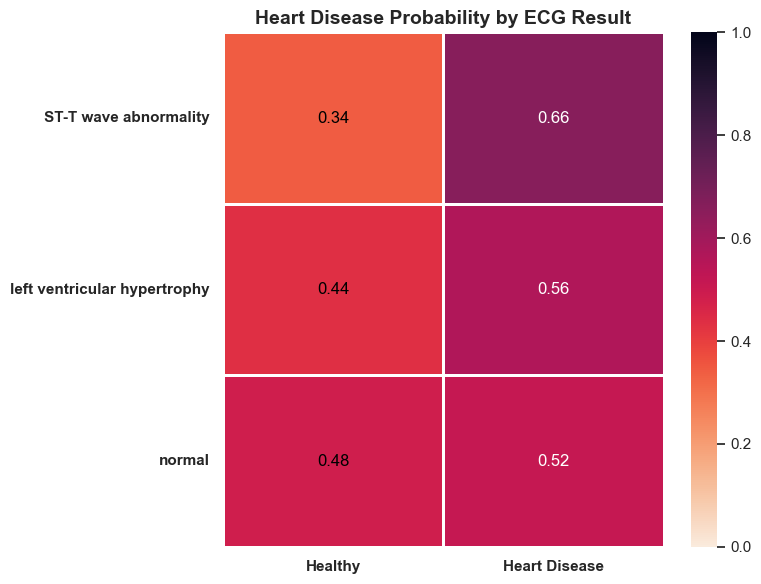

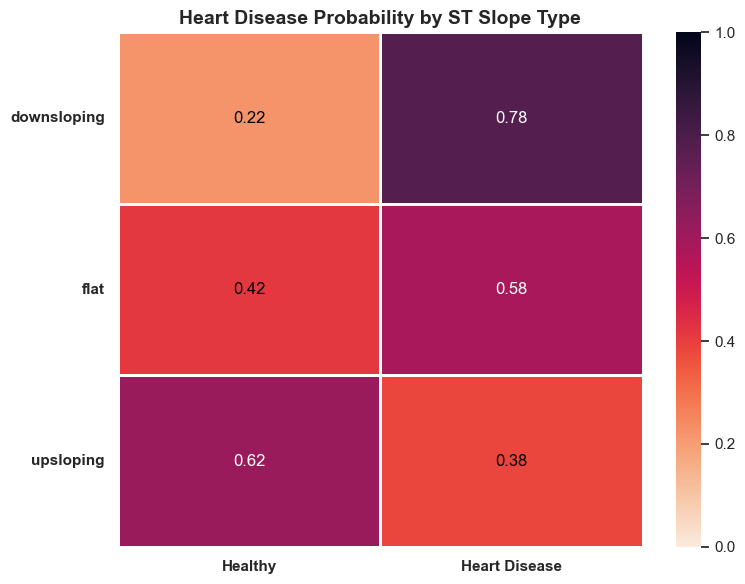

In [55]:
def plot_heatmap_probability(data, column, labels_dict, title):
    df = data.copy()
    df['Condition'] = df['target'].map(lambda x: 'Heart Disease' if x > 0 else 'Healthy')
    ct = pd.crosstab(df[column], df['Condition'], normalize='index')
    ct.index = [labels_dict.get(x, x) for x in ct.index]
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(ct, annot=True, fmt=".2f", cmap="rocket_r",
                     vmin=0, vmax=1, linewidths=0.8, linecolor="white")
    for text in ax.texts:
        value = float(text.get_text())
        text.set_color("white" if value > 0.5 else "black")
    
    plt.title(title, fontweight='bold', fontsize=14)
    plt.ylabel("")
    plt.xlabel("")
    plt.xticks(fontweight='bold')
    plt.yticks(rotation=0, fontweight='bold')
    plt.tight_layout()
    plt.show()

cp_labels = {1.0: 'Typical Angina', 2.0: 'Atypical Angina', 
             3.0: 'Non-anginal Pain', 4.0: 'Asymptomatic'}
ecg_labels = {0.0: 'Normal', 1.0: 'ST-T Abnormality', 2.0: 'LV Hypertrophy'}
slope_labels = {1.0: 'Upsloping', 2.0: 'Flat', 3.0: 'Downsloping'}

plot_heatmap_probability(df, 'cp', cp_labels, "Heart Disease Probability by Chest Pain Type")
plot_heatmap_probability(df, 'restecg', ecg_labels, "Heart Disease Probability by ECG Result")
plot_heatmap_probability(df, 'slope', slope_labels, "Heart Disease Probability by ST Slope Type")

### Numerical Features Analysis

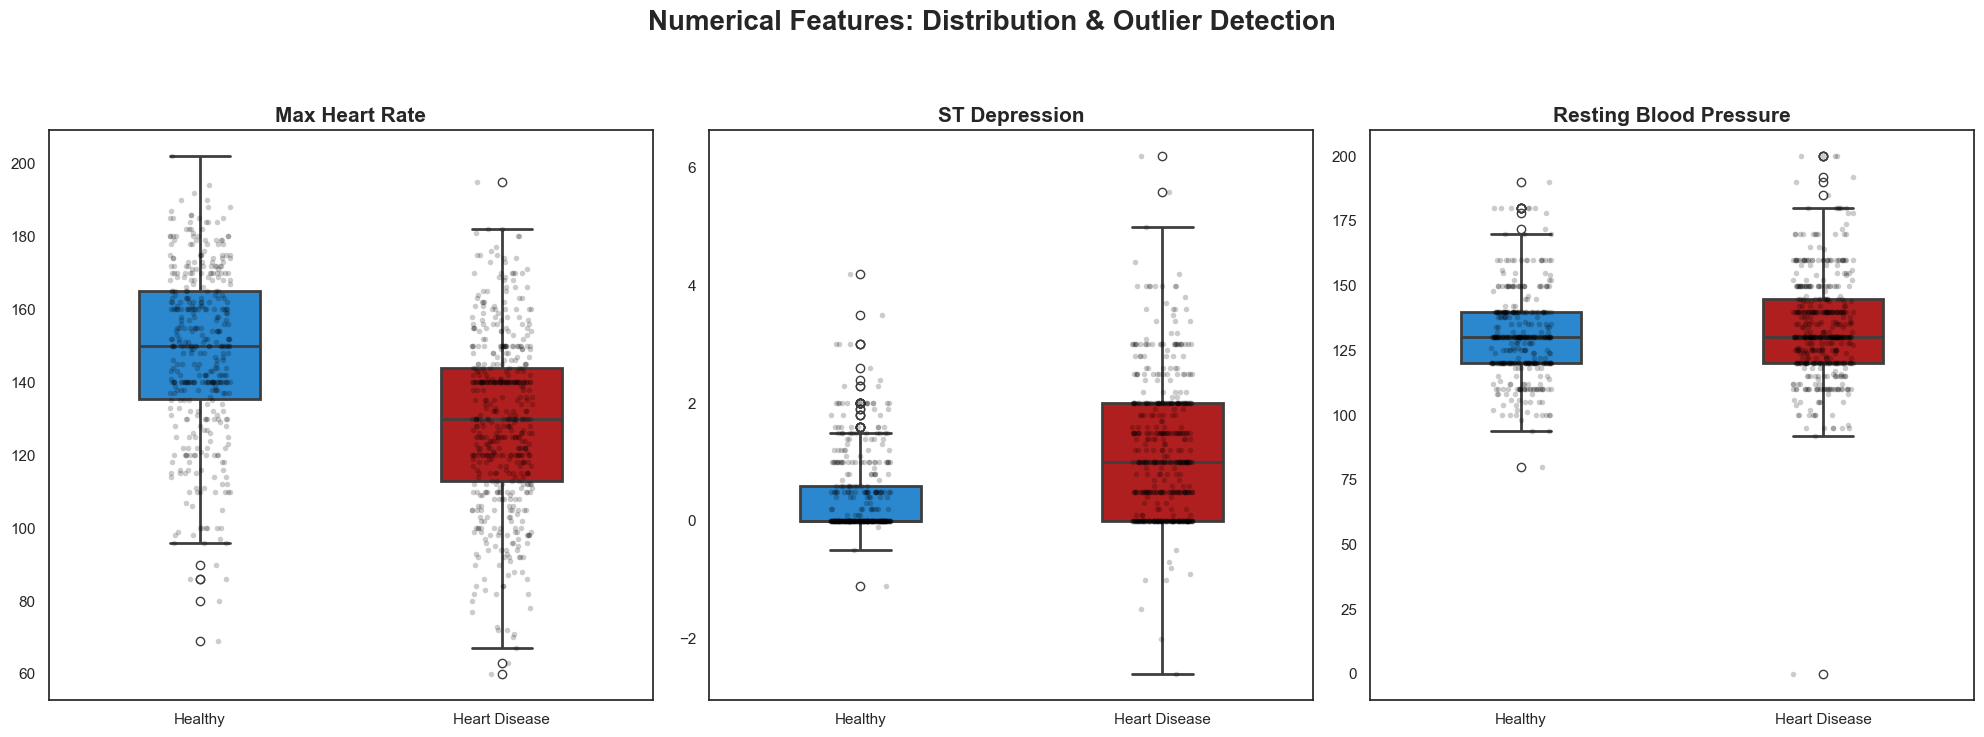

In [56]:
df['Condition'] = df['target'].apply(lambda x: 'Heart Disease' if x > 0 else 'Healthy')

features = ['thalach', 'oldpeak', 'trestbps']
titles = ['Max Heart Rate', 'ST Depression', 'Resting Blood Pressure']
colors = {'Healthy': "#108BE9", 'Heart Disease': "#C80707"}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
sns.set_theme(style="whitegrid")

for i, var in enumerate(features):
    sns.boxplot(data=df, x='Condition', y=var, ax=axes[i], 
                palette=colors, width=0.4, linewidth=2, hue='Condition', legend=False)
    sns.stripplot(data=df, x='Condition', y=var, ax=axes[i], 
                  color='black', alpha=0.2, size=4)
    axes[i].set_title(titles[i], fontsize=15, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.suptitle('Numerical Features: Distribution & Outlier Detection', fontsize=20, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Outlier Detection & Removal

In [57]:
df_numeric = df[['age', 'trestbps', 'chol', 'thalach']]
df_numeric.head()

,age,trestbps,chol,thalach
0,63.0,145.0,233.0,150.0
1,67.0,160.0,286.0,108.0
2,67.0,120.0,229.0,129.0
3,37.0,130.0,250.0,187.0
4,41.0,130.0,204.0,172.0


In [58]:
# calculating zscore of numeric columns in the dataset
z = np.abs(stats.zscore(df_numeric))
print(z)

[[1.00738556 0.70517639 0.30364317 0.4897271 ]
 [1.43203377 1.51856943 0.78996695 1.18147797]
 [1.43203377 0.65047866 0.26693949 0.34587544]
 ...
 [0.15808914 0.54202626 0.21188397 1.49980275]
 [0.4765753  0.10821664 1.69838307 0.09182113]
 [0.90122351 0.65047866 0.4963375  1.77833693]]


In [59]:
# Defining threshold for filtering outliers 
threshold = 3
print(np.where(z > 3))

(array([126, 152, 188, 338, 528, 546, 548, 631, 680, 701, 753, 896]), array([1, 2, 1, 1, 2, 2, 1, 3, 1, 1, 1, 1]))


In [60]:
#filtering outliers retaining only those data points which are below threshhold
df = df[(z < 3).all(axis=1)]

In [61]:
## encoding categorical variables
df = pd.get_dummies(df, drop_first=True)
df.head()

,age,trestbps,chol,fbs,thalach,exang,oldpeak,ca,thal,target,sex_male,cp_atypical angina,cp_non-anginal pain,cp_typical angina,restecg_left ventricular hypertrophy,restecg_normal,slope_flat,slope_upsloping,Condition_Heart Disease
0,63.0,145.0,233.0,1.0,150.0,0.0,2.3,0.0,6.0,0,True,False,False,True,True,False,False,False,False
1,67.0,160.0,286.0,0.0,108.0,1.0,1.5,3.0,3.0,2,True,False,False,False,True,False,True,False,True
2,67.0,120.0,229.0,0.0,129.0,1.0,2.6,2.0,7.0,1,True,False,False,False,True,False,True,False,True
3,37.0,130.0,250.0,0.0,187.0,0.0,3.5,0.0,3.0,0,True,False,True,False,False,True,False,False,False
4,41.0,130.0,204.0,0.0,172.0,0.0,1.4,0.0,3.0,0,False,True,False,False,True,False,False,True,False


In [62]:
df.shape

(908, 19)

In [63]:
# segregating dataset into features i.e., X and target variables i.e., y
X = df.drop(['target'],axis=1)
y = df['target']

## **Data Preparation**

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2,shuffle=True, random_state=5)

In [65]:
## checking distribution of target variable in train test split
print('Distribution of target variable in training set')
print(y_train.value_counts())

Distribution of target variable in training set
target
0    327
1    209
2     86
3     82
4     22
Name: count, dtype: int64


In [66]:
print('Distribution of target variable in test set')
print(y_test.value_counts())

Distribution of target variable in test set
target
0    82
1    52
2    22
3    21
4     5
Name: count, dtype: int64


In [67]:
# Save training and test set 
X_train.to_csv('X_train.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

## Feature normalization

In [68]:
X_train_clean = X_train.drop(columns=['Condition_Heart Disease'], errors='ignore')
X_test_clean = X_test.drop(columns=['Condition_Heart Disease'], errors='ignore')

In [69]:
cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'thal']
scaler = MinMaxScaler()

In [70]:
X_train_scaled = X_train_clean.copy()
X_test_scaled = X_test_clean.copy()

In [71]:
X_train_scaled[cols] = scaler.fit_transform(X_train_clean[cols])
X_test_scaled[cols] = scaler.transform(X_test_clean[cols])

In [72]:
X_train_scaled.to_csv('X_train_scaled.csv', index=False)
X_test_scaled.to_csv('X_test_scaled.csv', index=False)

## Feature Selection

**RFECV (Recursive Feature Elimination with Cross-Validation)**

In [73]:
y_train_bin = (y_train.values.flatten() > 0).astype(int)
y_test_bin = (y_test.values.flatten() > 0).astype(int)
model_lr = LogisticRegression(solver='liblinear', penalty='l1', C=0.1, random_state=42)

# RFECV Configuration (The Wrapper)
# Using 10-fold cross-validation for a more robust selection
rfecv_lr = RFECV(
    estimator=model_lr, 
    step=1, 
    cv=StratifiedKFold(5), 
    scoring='accuracy', 
    min_features_to_select=1, 
    n_jobs=-1
)

# Fit on the scaled training data
rfecv_lr.fit(X_train_scaled, y_train_bin)
print(f"Optimal number of features: {rfecv_lr.n_features_} out of 17")
print(f"Best Binary Accuracy (CV Score): {max(rfecv_lr.cv_results_['mean_test_score']):.4f}")

# Extract the selected feature names
selected_features = X_train_scaled.columns[rfecv_lr.support_]
print("\nSelected Features (Wrapper with Logistic Regression):")
print(selected_features.tolist())

Optimal number of features: 7 out of 17
Best Binary Accuracy (CV Score): 0.7741

Selected Features (Wrapper with Logistic Regression):
['chol', 'thalach', 'exang', 'thal', 'sex_male', 'cp_atypical angina', 'cp_non-anginal pain']


**Random Forest Feature Importance**

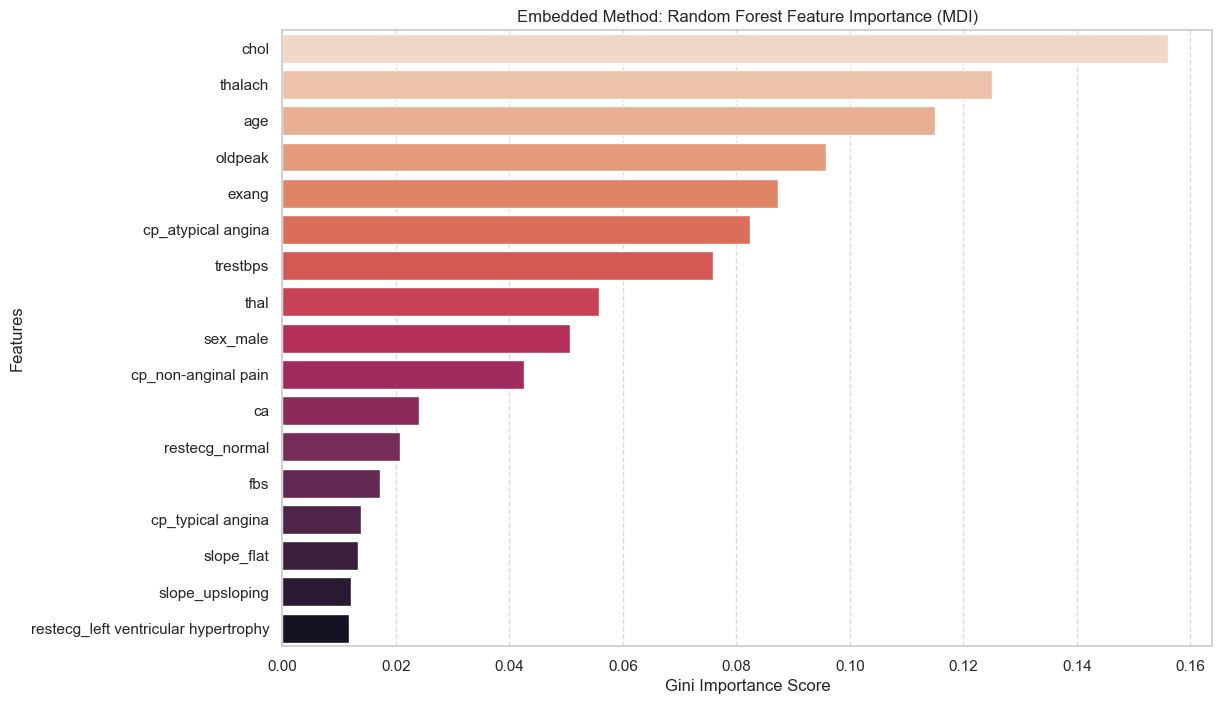

Full Feature Ranking:
                                 Feature  Importance
2                                   chol    0.156052
4                                thalach    0.125077
0                                    age    0.114915
6                                oldpeak    0.095856
5                                  exang    0.087356
10                    cp_atypical angina    0.082454
1                               trestbps    0.075887
8                                   thal    0.055803
9                               sex_male    0.050715
11                   cp_non-anginal pain    0.042511
7                                     ca    0.024133
14                        restecg_normal    0.020784
3                                    fbs    0.017273
12                     cp_typical angina    0.013930
15                            slope_flat    0.013355
16                       slope_upsloping    0.012154
13  restecg_left ventricular hypertrophy    0.011743


In [74]:
# 1. Initialize and fit the Random Forest on all 17 features
# We use the binary target (y_train_bin) for consistency
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train_bin)

# 2. Extract feature importance
importances = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 3. Visualization
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importances, palette='rocket_r')
plt.title('Embedded Method: Random Forest Feature Importance (MDI)')
plt.xlabel('Gini Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 4. Display the ranking
print("Full Feature Ranking:")
print(importances)

## **Model Training and Evaluation**

In [75]:
top_10_features = importances.head(10)['Feature'].tolist()

X_train_final = X_train_scaled[top_10_features]
X_test_final = X_test_scaled[top_10_features]

print(f"Features selected: {top_10_features}")

Features selected: ['chol', 'thalach', 'age', 'oldpeak', 'exang', 'cp_atypical angina', 'trestbps', 'thal', 'sex_male', 'cp_non-anginal pain']


### Logistic Regression

In [76]:
lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100], 
    'penalty': ['l2'],                       
    'solver': ['liblinear', 'lbfgs']         
}
lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    lr_params,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

lr_grid.fit(X_train_final, y_train_bin)

print("Best C found:", lr_grid.best_params_['C'])
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test_bin, lr_grid.predict(X_test_final), target_names=['Healthy', 'Heart Disease']))

Best C found: 10

Classification Report (Logistic Regression):
               precision    recall  f1-score   support

      Healthy       0.86      0.80      0.83        82
Heart Disease       0.85      0.89      0.87       100

     accuracy                           0.85       182
    macro avg       0.85      0.85      0.85       182
 weighted avg       0.85      0.85      0.85       182



### Gaussian Naive Bayes

In [77]:
gnb_params = {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]}

gnb_grid = GridSearchCV(
    GaussianNB(),
    gnb_params,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

gnb_grid.fit(X_train_final, y_train_bin)

print("Best var_smoothing found:", gnb_grid.best_params_['var_smoothing'])
print("\nClassification Report (Gaussian Naive Bayes):")
print(classification_report(y_test_bin, gnb_grid.predict(X_test_final), target_names=['Healthy', 'Heart Disease']))

Best var_smoothing found: 1e-09

Classification Report (Gaussian Naive Bayes):
               precision    recall  f1-score   support

      Healthy       0.85      0.82      0.83        82
Heart Disease       0.85      0.88      0.87       100

     accuracy                           0.85       182
    macro avg       0.85      0.85      0.85       182
 weighted avg       0.85      0.85      0.85       182



### SVM Tuning

In [78]:
svm_params = {'C': list(range(1, 11)), 'kernel': ['rbf']}
svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    svm_params,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)
svm_grid.fit(X_train_final, y_train_bin)

print("Best C found:", svm_grid.best_params_['C'])
print("\nClassification Report (SVM):")
print(classification_report(y_test_bin, svm_grid.predict(X_test_final), target_names=['Healthy', 'Heart Disease']))

Best C found: 4

Classification Report (SVM):
               precision    recall  f1-score   support

      Healthy       0.88      0.73      0.80        82
Heart Disease       0.81      0.92      0.86       100

     accuracy                           0.84       182
    macro avg       0.84      0.83      0.83       182
 weighted avg       0.84      0.84      0.83       182



### Random Forest Tuning

In [79]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5]
}

rf_model = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_params,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

rf_grid.fit(X_train_final, y_train_bin)

print("Best Parameters found:", rf_grid.best_params_)
print("\nClassification Report:")
print(classification_report(y_test_bin, rf_grid.predict(X_test_final), target_names=['Healthy', 'Heart Disease']))

Best Parameters found: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}

Classification Report:
               precision    recall  f1-score   support

      Healthy       0.91      0.77      0.83        82
Heart Disease       0.83      0.94      0.88       100

     accuracy                           0.86       182
    macro avg       0.87      0.85      0.86       182
 weighted avg       0.87      0.86      0.86       182



### Final Evaluation on Test Set

In [80]:
final_models = {
    "Logistic Regression": lr_grid.best_estimator_,
    "Gaussian Naive Bayes": gnb_grid.best_estimator_,
    "SVM": svm_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_
}

evaluation_results = {}

for name, model in final_models.items():
    y_pred = model.predict(X_test_final)
    evaluation_results[name] = {
        "Accuracy": accuracy_score(y_test_bin, y_pred),
        "Recall": recall_score(y_test_bin, y_pred),
        "Macro-F1 Score": f1_score(y_test_bin, y_pred, average="macro"),
        "MCC": matthews_corrcoef(y_test_bin, y_pred)
    }

results_df = pd.DataFrame(evaluation_results).T.round(4)
print(" FINAL MODEL COMPARISON (Test Set Performance)")
results_df.sort_values(by="MCC", ascending=False)

 FINAL MODEL COMPARISON (Test Set Performance)


,Accuracy,Recall,Macro-F1 Score,MCC
Random Forest,0.8626,0.94,0.8585,0.7264
Logistic Regression,0.8516,0.89,0.8492,0.6998
Gaussian Naive Bayes,0.8516,0.88,0.8496,0.6998
SVM,0.8352,0.92,0.8299,0.6703


## FINAL EVALUATION:

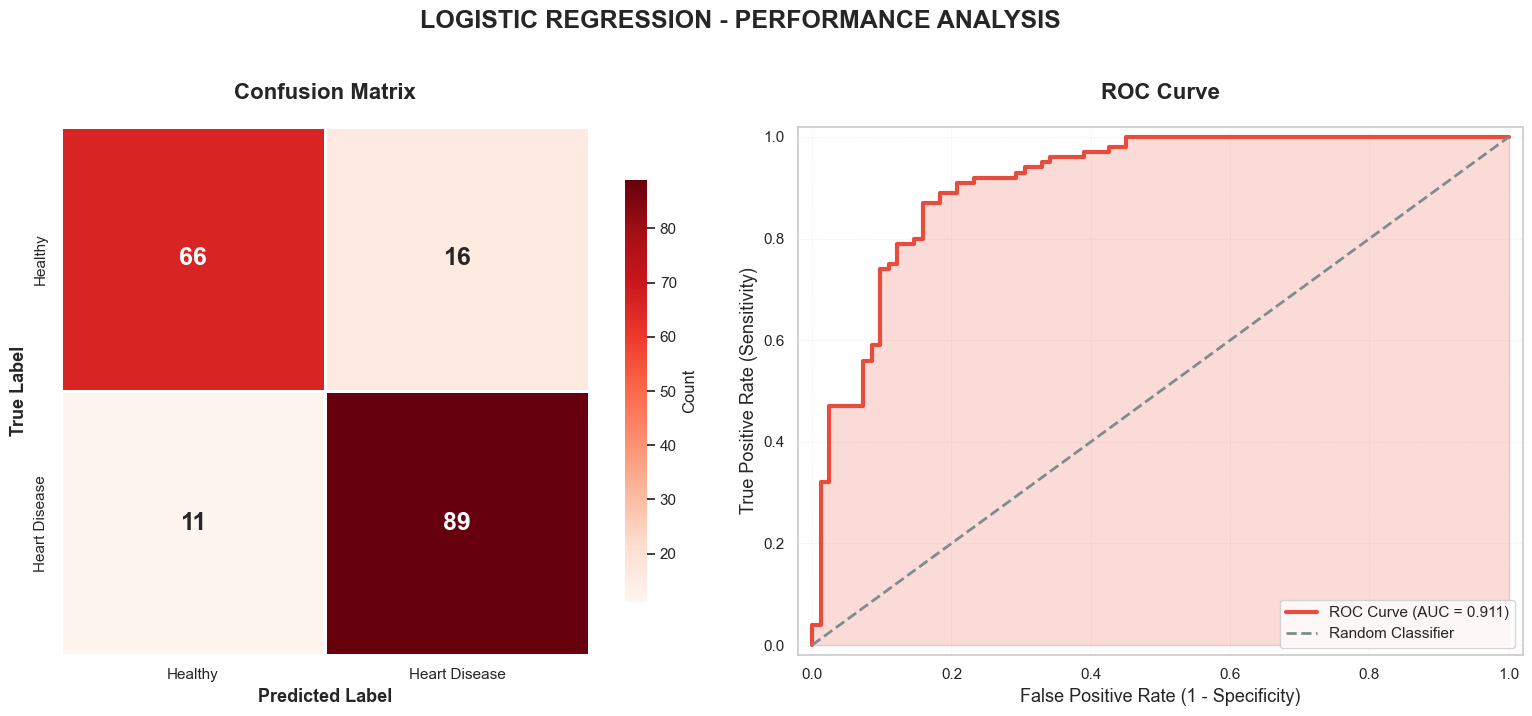

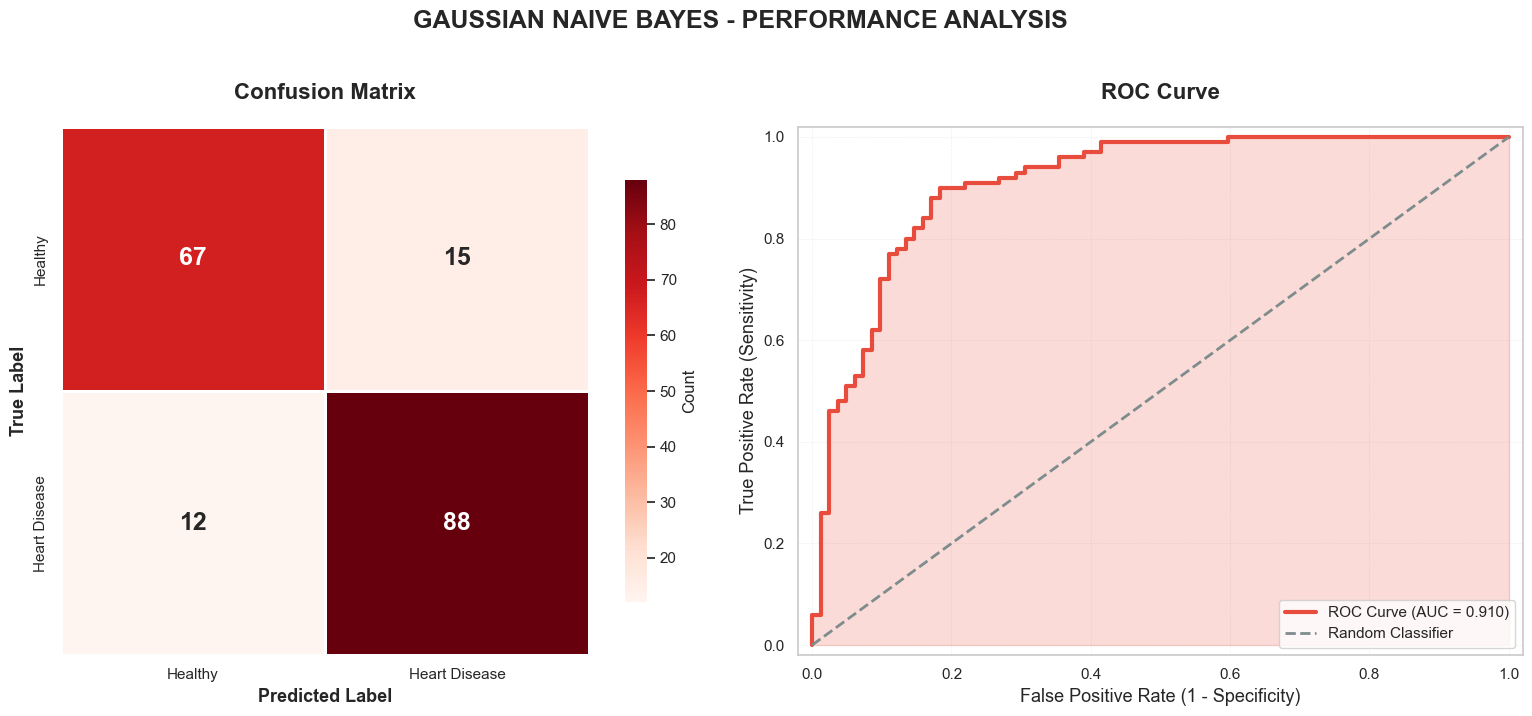

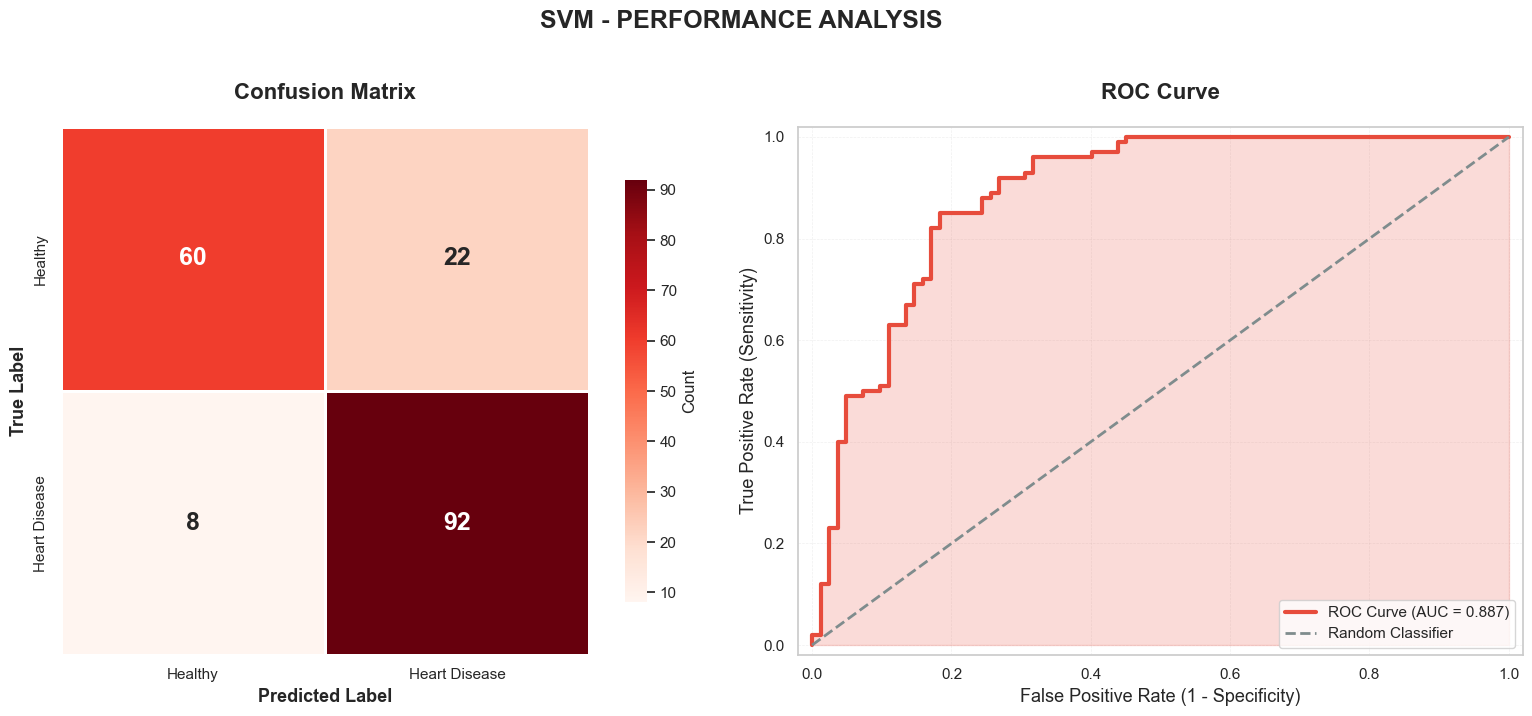

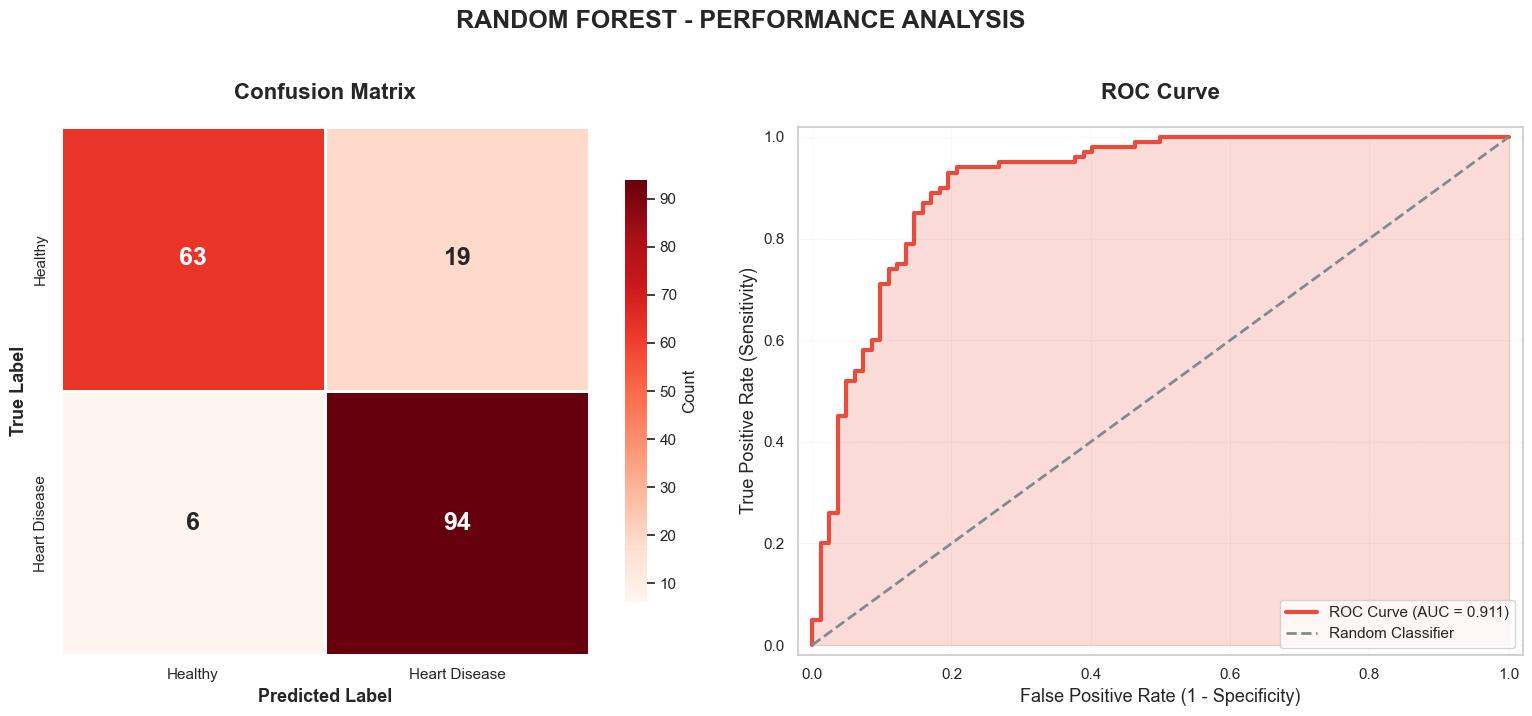

In [81]:
def evaluate_model(model, X_test, y_test, model_name, classes=['Healthy', 'Heart Disease']):
    """
    Evaluates a model, calculates metrics and produces figure with Confusion Matrix and ROC Curve.
    """
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy = accuracy_score(y_test, y_pred)
    sensitivity = recall_score(y_test, y_pred)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # Confusion Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax1,
                xticklabels=classes, yticklabels=classes,
                cbar_kws={'label': 'Count', 'shrink': 0.8},
                annot_kws={'size': 18, 'weight': 'bold'},
                linewidths=2, linecolor='white', square=True)
    ax1.set_title('Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
    ax1.set_xlabel('Predicted Label', fontsize=13, fontweight='semibold')
    ax1.set_ylabel('True Label', fontsize=13, fontweight='semibold')

    # ROC Curve
    ax2.plot(fpr, tpr, color='#e74c3c', lw=3, label=f'ROC Curve (AUC = {roc_auc:.3f})')
    ax2.fill_between(fpr, tpr, alpha=0.2, color='#e74c3c')
    ax2.plot([0, 1], [0, 1], color='#7f8c8d', lw=2, linestyle='--', label='Random Classifier')
    ax2.set_xlim([-0.02, 1.02]); ax2.set_ylim([-0.02, 1.02])
    ax2.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=13)
    ax2.set_ylabel('True Positive Rate (Sensitivity)', fontsize=13)
    ax2.set_title('ROC Curve', fontsize=16, fontweight='bold', pad=20)
    ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax2.legend(loc='lower right', fontsize=11)

    fig.suptitle(f'{model_name} - PERFORMANCE ANALYSIS', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Return metrics for later use
    return {
        'accuracy': accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'precision': precision,
        'f1': f1,
        'roc_auc': roc_auc
    }

# COMPLETE ANALYSIS FOR ALL MODELS
print("="*150)
results_lr = evaluate_model(lr_grid.best_estimator_, X_test_final, y_test_bin, "LOGISTIC REGRESSION")
print("="*150)

results_gnb = evaluate_model(gnb_grid.best_estimator_, X_test_final, y_test_bin, "GAUSSIAN NAIVE BAYES")
print("="*150)

results_svm = evaluate_model(svm_grid.best_estimator_, X_test_final, y_test_bin, "SVM")
print("="*150)

results_rf = evaluate_model(rf_grid.best_estimator_, X_test_final, y_test_bin, "RANDOM FOREST")
print("="*150)

In [82]:
# Collect all results in a dictionary
all_results = {
    'Logistic Regression': results_lr,
    'Gaussian Naive Bayes': results_gnb,
    'SVM': results_svm,
    'Random Forest': results_rf
}

# Create DataFrame for clear comparison
import pandas as pd
comparison_df = pd.DataFrame(all_results).T.round(4)
print("\n", comparison_df)



                       accuracy  sensitivity  specificity  precision      f1  \
Logistic Regression     0.8516         0.89       0.8049     0.8476  0.8683   
Gaussian Naive Bayes    0.8516         0.88       0.8171     0.8544  0.8670   
SVM                     0.8352         0.92       0.7317     0.8070  0.8598   
Random Forest           0.8626         0.94       0.7683     0.8319  0.8826   

                      roc_auc  
Logistic Regression    0.9106  
Gaussian Naive Bayes   0.9104  
SVM                    0.8874  
Random Forest          0.9107  


In [83]:
# SAVE MODELS 
# Create folder for models
os.makedirs('models', exist_ok=True)

# Save all models
joblib.dump(lr_grid.best_estimator_, 'models/logistic_regression.joblib')
joblib.dump(gnb_grid.best_estimator_, 'models/naive_bayes.joblib')
joblib.dump(svm_grid.best_estimator_, 'models/svm.joblib')
joblib.dump(rf_grid.best_estimator_, 'models/random_forest.joblib')

# Also save scaler and feature names (useful for future predictions)
joblib.dump(scaler, 'models/scaler.joblib')

with open('models/feature_names.txt', 'w') as f:
    for feat in X_train_final.columns:
        f.write(f"{feat}\n")
print("Feature names saved")

Feature names saved


In [86]:
# BEST MODEL FOR EACH METRIC
comparison_df.to_csv('model_comparison.csv')

print("\nBEST MODEL FOR EACH METRIC")
metrics = ['accuracy', 'sensitivity', 'specificity', 'precision', 'f1', 'roc_auc']
for metric in metrics:
    best = comparison_df[metric].idxmax()
    print(f"{metric:12s}: {best} ({comparison_df.loc[best, metric]:.4f})")

# Save best models summary
best_models_df = pd.DataFrame([
    [m, comparison_df[m].idxmax(), comparison_df.loc[comparison_df[m].idxmax(), m]]
    for m in metrics
], columns=['Metric', 'Best Model', 'Best Value'])
best_models_df.to_csv('best_models_per_metric.csv', index=False)


BEST MODEL FOR EACH METRIC
accuracy    : Random Forest (0.8626)
sensitivity : Random Forest (0.9400)
specificity : Gaussian Naive Bayes (0.8171)
precision   : Gaussian Naive Bayes (0.8544)
f1          : Random Forest (0.8826)
roc_auc     : Random Forest (0.9107)
